In [22]:
import pandas as pd 

df0 = pd.read_csv("prices_round_1_day_0.csv", sep=';')
df1 = pd.read_csv("prices_round_1_day_-1.csv", sep=';')
df2 = pd.read_csv("prices_round_1_day_-2.csv", sep=';')
df1['timestamp'] = df1['timestamp'] + int(1e6)
df0['timestamp'] = df0['timestamp'] + int(2e6)
df = pd.concat([df1, df2])

In [23]:
df[df['bid_price_1'] > 0]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,1000000,INTARIAN_PEPPER_ROOT,10991.0,15.0,NaN,NaN,NaN,NaN,11006.0,10.0,11009.0,15.0,NaN,NaN,10998.5,0.0
2,-1,1000100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0
3,-1,1000100,INTARIAN_PEPPER_ROOT,10994.0,9.0,10991.0,21.0,NaN,NaN,11006.0,9.0,11009.0,21.0,NaN,NaN,11000.0,0.0
4,-1,1000200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0
5,-1,1000200,INTARIAN_PEPPER_ROOT,10994.0,10.0,NaN,NaN,NaN,NaN,11009.0,20.0,NaN,NaN,NaN,NaN,11001.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-2,999700,ASH_COATED_OSMIUM,9984.0,10.0,9982.0,22.0,NaN,NaN,10000.0,10.0,10003.0,22.0,NaN,NaN,9992.0,0.0
19996,-2,999800,INTARIAN_PEPPER_ROOT,10994.0,11.0,10991.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10994.0,0.0
19997,-2,999800,ASH_COATED_OSMIUM,9984.0,14.0,9982.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9984.0,0.0
19998,-2,999900,INTARIAN_PEPPER_ROOT,10994.0,8.0,NaN,NaN,NaN,NaN,11009.0,20.0,NaN,NaN,NaN,NaN,11001.5,0.0


In [24]:
df.shape

(40000, 17)

In [25]:
df_tomatoes = df[df['product'] == 'ASH_COATED_OSMIUM']
df_emeralds =  df[df['product'] == 'INTARIAN_PEPPER_ROOT']

In [26]:
df_emeralds[df_emeralds['bid_price_2'] == 9990]['bid_volume_2'].unique()

array([], dtype=float64)

In [27]:
print(df_emeralds['ask_volume_1'].unique())
print(df_emeralds['bid_volume_1'].unique())

[10.  9. 20. 11.  8. 25. 12. nan 19. 16. 18.  7. 15. 22.  4. 17. 21.  6.
  5. 24. 23.  3.  1.]
[15.  9. 10. nan 20.  8. 12.  6. 19. 11. 24. 25. 18. 23. 21. 16. 17.  5.
  3. 22.  4.  7.  2.]


In [28]:
print("Shape of tomates:", df_tomatoes.shape)
print("Shape of emeralds:", df_emeralds.shape)

Shape of tomates: (20000, 17)
Shape of emeralds: (20000, 17)


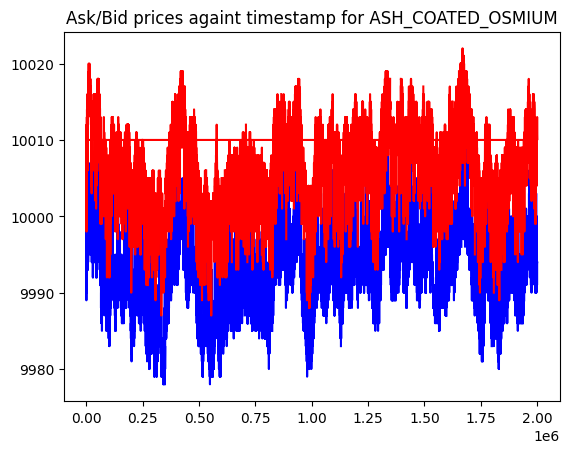

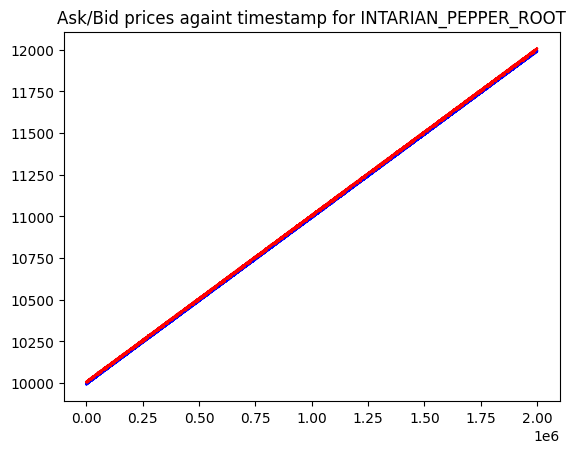

In [29]:
import matplotlib.pyplot as plt

def plot_prices(df, asset):
    x = df['timestamp']
    bid1 = df['bid_price_1']
    ask1 = df['ask_price_1']
    # plt.figure()
    plt.title(label=f"Ask/Bid prices againt timestamp for {asset}")
    plt.plot(x, bid1, color='blue')
    plt.plot(x, ask1, color='red')
    plt.show()

plot_prices(df_tomatoes, "ASH_COATED_OSMIUM")
plot_prices(df_emeralds, "INTARIAN_PEPPER_ROOT")


In [30]:
import pandas as pd 

df0 = pd.read_csv("trades_round_1_day_0.csv", sep=';')
df1 = pd.read_csv("trades_round_1_day_-1.csv", sep=';')
df2 = pd.read_csv("trades_round_1_day_-2.csv", sep=';')
df1['timestamp'] = df1['timestamp'] + int(1e6)
df0['timestamp'] = df0['timestamp'] + int(2e6)
df = pd.concat([df1, df2])

In [31]:
df.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,1002800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9985.0,10
1,1003000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10999.0,8
2,1004200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10995.0,4
3,1005200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10004.0,6
4,1005200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9986.0,9


In [32]:
df_emeralds = df[df['symbol'] == "EMERALDS"]

In [33]:
df_emeralds_buy = df_emeralds[df_emeralds['price'] < 10000]
df_emeralds_sell = df_emeralds[df_emeralds['price'] > 10000]

In [34]:
df_emeralds_buy.head()

,timestamp,buyer,seller,symbol,currency,price,quantity


In [35]:
print(df_emeralds_buy['quantity'].unique())
print(df_emeralds_sell['quantity'].unique())

[]
[]


In [36]:
print(df_emeralds_buy['price'].value_counts())
print(df_emeralds_sell['price'].value_counts())


Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [37]:
df_tomatoes.head(20)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,-1,1000000,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.0,29.0,NaN,NaN,NaN,NaN,10003.0,0.0
2,-1,1000100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0
4,-1,1000200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0
7,-1,1000300,ASH_COATED_OSMIUM,9985.0,11.0,9982.0,29.0,NaN,NaN,10001.0,11.0,10003.0,29.0,NaN,NaN,9993.0,0.0
9,-1,1000400,ASH_COATED_OSMIUM,9985.0,12.0,NaN,NaN,NaN,NaN,10001.0,12.0,10004.0,25.0,NaN,NaN,9993.0,0.0
10,-1,1000500,ASH_COATED_OSMIUM,9985.0,12.0,9983.0,30.0,NaN,NaN,10001.0,12.0,10004.0,30.0,NaN,NaN,9993.0,0.0
12,-1,1000600,ASH_COATED_OSMIUM,9983.0,25.0,NaN,NaN,NaN,NaN,10004.0,25.0,NaN,NaN,NaN,NaN,9993.5,0.0
15,-1,1000700,ASH_COATED_OSMIUM,9983.0,23.0,NaN,NaN,NaN,NaN,10004.0,23.0,NaN,NaN,NaN,NaN,9993.5,0.0
17,-1,1000800,ASH_COATED_OSMIUM,9985.0,15.0,NaN,NaN,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0
18,-1,1000900,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,22.0,NaN,NaN,10001.0,15.0,10003.0,22.0,NaN,NaN,9993.0,0.0


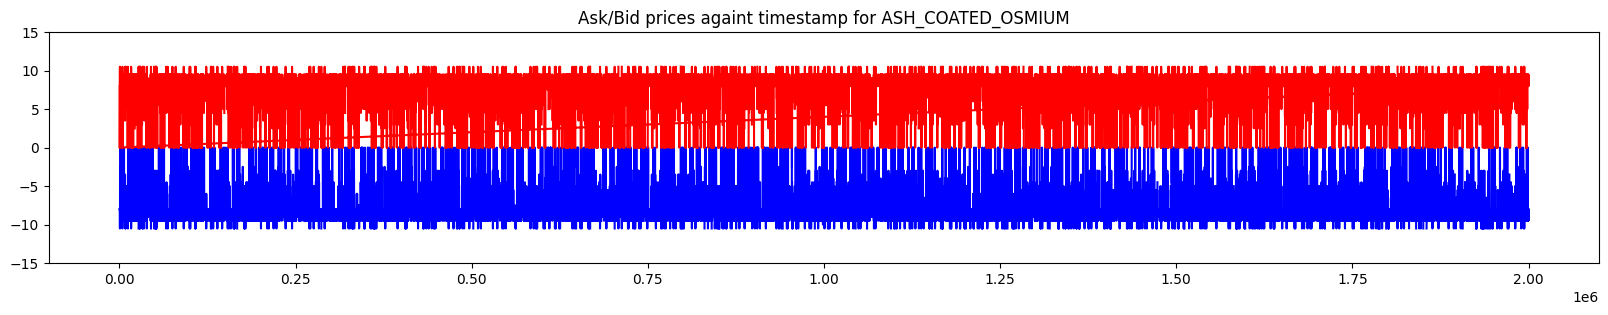

In [42]:
import warnings

def plot_mr(df, asset):
    x = df['timestamp']
    bid1 = df['d_bid_price_1']
    ask1 = df['d_ask_price_1']
    mid = df['d_mid_price']
    plt.figure(figsize=(20, 3))
    plt.title(label=f"Ask/Bid prices againt timestamp for {asset}")
    plt.plot(x, bid1, color='blue')
    plt.plot(x, ask1, color='red')
    # plt.plot(x, mid, color='green')

    plt.ylim(-15, 15)
    plt.show()
window = 5
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df_tomatoes["ma"] = df_tomatoes["mid_price"].rolling(window=window).mean()
    df_tomatoes["d_bid_price_1"] = df_tomatoes["bid_price_1"] - df_tomatoes["mid_price"]
    df_tomatoes["d_ask_price_1"] = df_tomatoes["ask_price_1"] - df_tomatoes["mid_price"]
    df_tomatoes["d_mid_price"] = df_tomatoes["mid_price"] - df_tomatoes["ma"]
import matplotlib.pyplot as plt

plot_mr(df_tomatoes, "ASH_COATED_OSMIUM")

In [39]:
df_tomatoes["shift_mid_price"] = df_tomatoes['mid_price'] - df_tomatoes['mid_price'].shift(1)

In [40]:
df_tomatoes['shift_mid_price'].unique()

array([         nan, -1.10000e+01,  1.00000e+00,  0.00000e+00,
        5.00000e-01, -5.00000e-01, -1.00000e+00,  1.50000e+00,
       -1.50000e+00, -2.00000e+00, -7.00000e+00,  8.00000e+00,
        3.50000e+00,  2.50000e+00, -3.50000e+00,  5.50000e+00,
       -4.50000e+00,  4.50000e+00, -1.00000e+01,  9.50000e+00,
        2.00000e+00, -5.00000e+00,  3.00000e+00, -2.50000e+00,
        5.00000e+00, -4.00000e+00, -8.00000e+00, -3.00000e+00,
        4.00000e+00,  9.00000e+00, -5.50000e+00, -9.99700e+03,
        9.99700e+03, -6.00000e+00,  6.00000e+00,  7.00000e+00,
       -1.15000e+01, -9.00000e+00,  6.50000e+00,  1.15000e+01,
        1.10000e+01, -1.20000e+01, -1.00025e+04,  1.00030e+04,
       -8.50000e+00,  1.00000e+01, -1.60000e+01, -1.00000e+04,
        1.00100e+04, -2.10000e+01,  7.50000e+00, -6.50000e+00,
       -7.50000e+00,  1.20000e+01,  1.00065e+04,  8.50000e+00,
        1.25000e+01,  1.60000e+01, -9.50000e+00,  1.90000e+01,
        9.99900e+03, -1.25000e+01,  1.40000e+01,  1.050